# Automated Data Collection Tool
**Authors:** Dickson Owuor, Raymond Cao

July 2025

## Main Goal

To write a function that will take as input: (1) a CSV file with image filters and (2) microscopy images. The function will apply filters to the images to produce graph images. The images will be later labeled as good/bad in order to be used to train a CNN model to detect/predict good and bad graph images.

### 1. Import Libraries

In [1]:
# Installing Libraries (if not installed)
#!pip3 install matplotlib
#!pip3 install sgtlib
#!pip3 install seaborn
#!pip3 install numpy
#!pip3 install pandas

In [2]:
import os
import pandas as pd
import matplotlib.image as mpimg
from sgtlib import modules as sgt
from matplotlib import pyplot as plt

### 2. Get CSV file and Image Folder

In [3]:
# Read CSV file into a Pandas DataFram

filter_df = pd.read_csv('../train_data/manual/filters.csv')
filter_df.head()

,file_name,Adaptive Kernel,Global Threshold,OTSU,Dark FG,Autolevel,Gaussian Kernel,Laplacian,Sobel,Median,Scharr,Lowpass Window,Gamma,result
0,ANF.jpeg,21.0,NaN,NaN,NaN,7.0,7.0,NaN,NaN,True,NaN,3.0,0.94,G
1,ANF.jpeg,23.0,NaN,NaN,NaN,7.0,7.0,NaN,NaN,True,NaN,4.0,0.94,G
2,ANF.jpeg,25.0,NaN,NaN,NaN,7.0,7.0,NaN,NaN,True,NaN,3.0,0.97,G
3,ANF.jpeg,23.0,NaN,NaN,NaN,7.0,7.0,NaN,NaN,True,NaN,3.0,0.93,G
4,ANF.jpeg,11.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,True,NaN,2.0,0.85,B


In [4]:
# Load images folder
data_dir = '../images'
os.listdir(data_dir)
print(os.listdir(data_dir))

['4.tif', '4_002.tif', '4_004.tif', 'a (2).jpg', 'a (4).BMP', 'ANF.jpeg', 'b (12).tif', 'b (14).tif', 'b (5).tif', 'c (1).tif', 'c (3).tif', 'c (6).tif', 'CANF.jpeg', 'CANN.jpeg', 'CCF.jpeg', 'd (2).tif', 'd (4).tif', 'd (6).tif', 'e (10).tif', 'e (4).tif', 'e (6).tif', 'f (3).tif', 'f (4).tif', 'f (7).tif', 'FCF.jpeg', 'h (1).tif', 'h (5).tif', 'h (7).tif', 'i (3).tif', 'i (5).tif', 'i (8).tif', 'j (5).tif', 'j (6).tif', 'j (7).tif', 'rGO.jpeg']


(662, 909, 3)


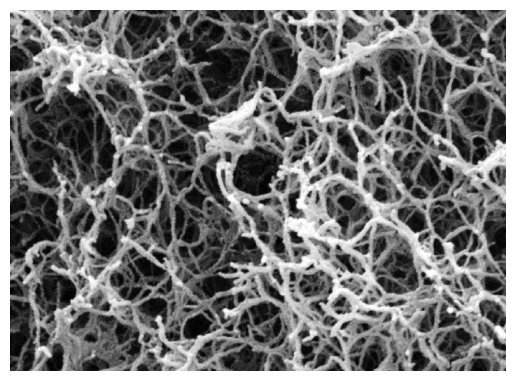

In [5]:
# Check out images

img = mpimg.imread('../images/ANF.jpeg')
print(img.shape)
plt.imshow(img)
plt.axis('off')
plt.show()

### 3. Run StructuralGT

* Identify and set paths to image(s) and config file

In [6]:
# set paths
img_path = "../images/ANF.jpeg"
cfg_file = "sgt_configs.ini"  # Optional: leave blank

* Define a function that will allow you to receive live updates from StructuralGT (as it is running)

In [7]:
# Define a function for receiving progress updates
def print_updates(progress_val, progress_msg):
    print(f"{progress_val}: {progress_msg}")

* Create an object that will take as input the config file and image and apply image filter

In [8]:
# Create a Network object
ntwk_obj, _ = sgt.ImageProcessor.create_imp_object(img_path)

../images/ANF.jpeg
INFO: Image is 2D.


* Update image filter options

In [9]:
img_obj = ntwk_obj.image_obj
print(f"Old Threshold Type: {img_obj.configs["threshold_type"]["value"]}")

img_obj.configs["threshold_type"]["value"] = 1
print(f"New Threshold Type: {img_obj.configs["threshold_type"]["value"]}")

Old Threshold Type: 0
New Threshold Type: 1


* Apply image filters according to config file

In [10]:
# Apply image filters according to cfg_file
ntwk_obj.add_listener(print_updates)
ntwk_obj.apply_img_filters()
ntwk_obj.remove_listener(print_updates)

10: Processing image...
99.0: Image processing in progress...
100: Image processing complete...


In [11]:
# Get images
bin_image = ntwk_obj.binary_image_2d
mod_image = ntwk_obj.processed_image_2d

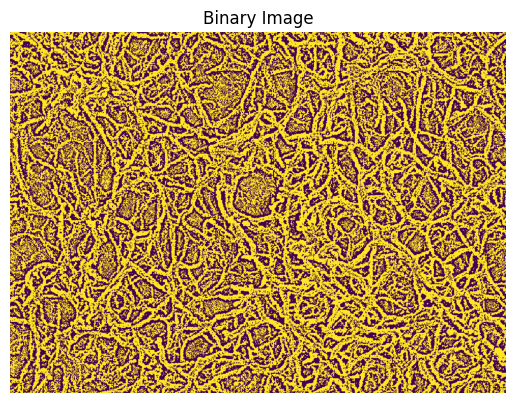

In [12]:
# View images
plt.imshow(bin_image)
plt.axis('off')  # Optional: Turn off axis ticks and labels for a cleaner image display
plt.title('Binary Image')
plt.show()

* Extract the graph

In [13]:
# Extract graph
ntwk_obj.add_listener(print_updates)
ntwk_obj.build_graph_network()
ntwk_obj.remove_listener(print_updates)

0: Starting graph extraction...
50: Extracting the graph network...
51: Build graph skeleton from binary image...
52: Ran merge_nodes for image skeleton...
54: Ran remove_small_objects for image skeleton...
56: Ran prune_dangling_edges for image skeleton...
60: Creating graph network...
64: Removing self loops from graph network...
66: Assigning weights to graph network...
75: Verifying graph network...
77: Retrieving graph properties...
78: Identifying graph subcomponents...
80: Storing graph properties...
90: Saving graph network...
INFO: overwriting file: ..\images\sgt_files\ANF_skel.gsd with mode: w, application: gsd.hoomd 4.0.0, schema: hoomd, and schema_version: [1, 4]
INFO: opening HOOMDTrajectory: <gsd.fl.GSDFile object at 0x0000016BC57BDD20>
INFO: found 0 frames
INFO: closing file: ..\images\sgt_files\ANF_skel.gsd
95: Plotting graph network...


* View the graph image

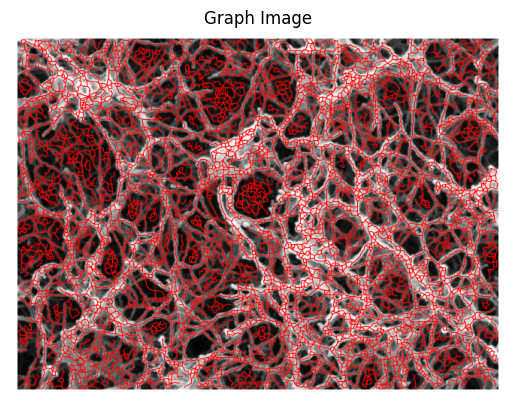

In [14]:
# View graph
net_image = ntwk_obj.graph_image
plt.imshow(net_image)
plt.axis('off')  # Optional: Turn off axis ticks and labels for a cleaner image display
plt.title('Graph Image')
plt.show()

In [1]:
## Import from local directory
from src.gen_graphs import automated_graph_generator


In [ ]:
automated_graph_generator(images_dir="../images", out_dir="../train_data/auto/auto_images_v1", loops=2, num_tries=2)